## This jupyter notebook is prepared by Sejal Mogalgiddi.

##Load Data and perform basic EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [ ]:
df= pd.read_csv('/content/hrdata2.csv')
rows,cols=df.shape
print(f"number of rows: {rows}")
print(f"number of columns: {cols}")

number of rows: 8955
number of columns: 15


In [ ]:
df.head()

,Unnamed: 0,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,>4,47,0.0
1,4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,21.0,50-99,Funded Startup,4,8,0.0
2,7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13.0,<10,Pvt Ltd,>4,18,1.0
3,8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7.0,50-99,Pvt Ltd,1,46,1.0
4,11,23853,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,5.0,5000-9999,Pvt Ltd,1,108,0.0


In [ ]:
df.tail()

,Unnamed: 0,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
8950,19147,21319,city_21,0.624,Male,No relevent experience,Full time course,Graduate,STEM,1.0,100-500,Pvt Ltd,1,52,1.0
8951,19149,251,city_103,0.920,Male,Has relevent experience,no_enrollment,Masters,STEM,9.0,50-99,Pvt Ltd,1,36,1.0
8952,19150,32313,city_160,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,10.0,100-500,Public Sector,3,23,0.0
8953,19152,29754,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,Humanities,7.0,10/49,Funded Startup,1,25,0.0
8954,19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21.0,50-99,Pvt Ltd,4,44,0.0


In [ ]:
number_nulls=df.isnull().sum()
print(number_nulls)

Unnamed: 0                0
enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64


There is 0 columns with null values -> this means there is no missing data

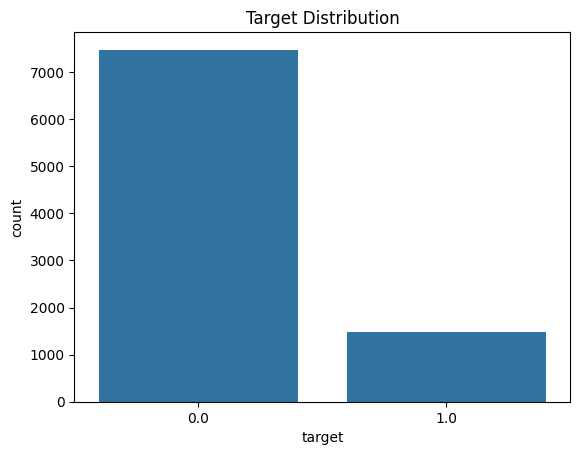

In [ ]:
#plot target distribution
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

###discussion

In the plot before we can see that there is some class imbalance as majority of our data displays 0 (not looking for job change) and minority of our data displays 1 (looking for job change).

We've learned that class imbalance leads to bias, poor predictions, and misleading accuracy scores.

To fix class imbalance we can use techniques like oversampling (SMOTE) or undersampling and switch out evalution metrics to precision, recall and f1-score

##Feature Selection and Pre-processing

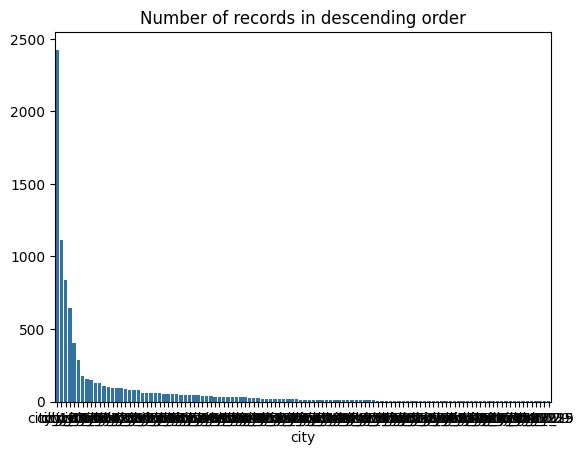

In [ ]:
#plot in descending
city_counts=df['city'].value_counts()

sns.barplot(x=city_counts.index, y=city_counts.values)

plt.title("Number of records in descending order")
plt.show()

We see the x axis to cluttered due to how many cities we have, the following code it reduced to the top 10 citites to get a closer look while being able to view the x axis

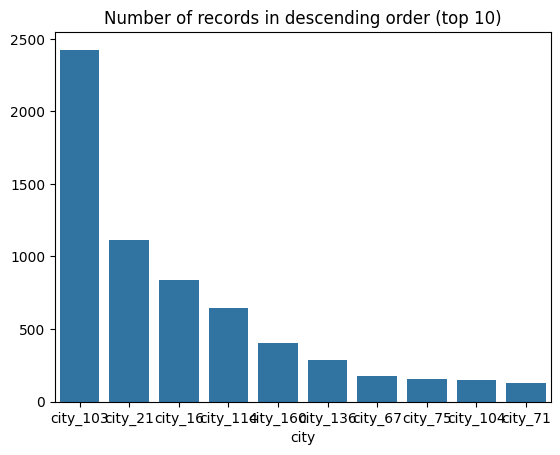

In [ ]:
#plot in descending
city_counts=df['city'].value_counts().head(10)
sns.barplot(x=city_counts.index, y=city_counts.values)

plt.title("Number of records in descending order (top 10)")
plt.show()

In [ ]:
#top 4
top_4= city_counts.head(4)
total=top_4.sum()
remain=len(df)-total
print("Top 4 cities:\n", top_4, "\n")
print("Rows in top 4 cities:", total, "\n")
print("Rows in remaining cities:", remain)

Top 4 cities:
 city
city_103    2426
city_21     1111
city_16      836
city_114     648
Name: count, dtype: int64 

Rows in top 4 cities: 5021 

Rows in remaining cities: 3934


In [ ]:
#replace
 # ~ flips
top_4_list=top_4.index.tolist()
print(top_4_list)
df.loc[~df['city'].isin(top_4_list), 'city'] = 'city_others'

#verfiy
df[['city']].head(10)


['city_103', 'city_21', 'city_16', 'city_114']


,city
0,city_others
1,city_others
2,city_others
3,city_103
4,city_103
5,city_others
6,city_114
7,city_others
8,city_114
9,city_others


In [ ]:
print(df[['city']].value_counts())

city       
city_others    3934
city_103       2426
city_21        1111
city_16         836
city_114        648
Name: count, dtype: int64


In [ ]:
#unique values
print(df['education_level'].unique())

#conversion
edu_map = {'Graduate':0, 'Masters': 1, 'Phd':2}
df['education_level']=df['education_level'].apply(lambda x: edu_map.get(x,x))

['Graduate' 'Masters' 'Phd']


In [ ]:
#verfiy
print(df['education_level'].value_counts())

education_level
0    6252
1    2449
2     254
Name: count, dtype: int64


In [ ]:
#unique vals for company
print(df['company_size'].unique())

['50-99' '<10' '5000-9999' '1000-4999' '10/49' '100-500' '10000+'
 '500-999']


In [ ]:
#conversion
size_map = {'<10':0, '10/49': 1, '50-99':2, '100-500':3, '500-999':4, '1000-4999':5, '5000-9999':6, '10000+':7}
df['company_size']=df['company_size'].apply(lambda x: size_map.get(x,x))

In [ ]:
#verfiy
print(df['company_size'].value_counts())


company_size
2    1986
3    1814
7    1449
1     951
5     930
0     840
4     592
6     393
Name: count, dtype: int64


In [ ]:
print(df['last_new_job'].unique())

['>4' '4' '1' '3' '2' 'never']


In [ ]:
#conversion
job_map = {'never':0, '1': 1, '2':2, '3':3, '4':4, '>4':5}
df['last_new_job']=df['last_new_job'].apply(lambda x: job_map.get(x,x))

In [ ]:
#verfiy
print(df['last_new_job'].value_counts())

last_new_job
1    3838
5    1965
2    1570
3     610
4     599
0     373
Name: count, dtype: int64


In [ ]:
cols=['company_type', 'major_discipline', 'enrolled_university', 'relevent_experience', 'gender', 'city']

for c in cols:
  print(f"\nUnique vals in {c}:")
  print(df[c].unique())


Unique vals in company_type:
['Pvt Ltd' 'Funded Startup' 'Early Stage Startup' 'Public Sector' 'NGO'
 'Other']

Unique vals in major_discipline:
['STEM' 'Humanities' 'Business Degree' 'Other' 'No Major' 'Arts']

Unique vals in enrolled_university:
['no_enrollment' 'Part time course' 'Full time course']

Unique vals in relevent_experience:
['No relevent experience' 'Has relevent experience']

Unique vals in gender:
['Male' 'Female' 'Other']

Unique vals in city:
['city_others' 'city_103' 'city_114' 'city_21' 'city_16']


In [ ]:
df=pd.get_dummies(df, columns=cols, dtype=int)

###Write a short paragraph about the differences between get_dummies and OneHotEncoder.

get_dummies is a pandas function while OneHotEncoder is part of sklearn. get_dummies primarily is used to do conversions of categorical variables and converts it to binary variables. This converts complex data into 0 and 1's which makes it easy for the code to analyze lots of categorical data cleanly and simple. OneHotEncoder is similar where is also converts categorical data into binary, its better at handling at unknown categoires we finding our dataset whereas get_dummies doesn't handle unknown categories well. OneHotEncoding is a little more flexibile and better to integrate in machine learning pipelines

In [ ]:
pd.set_option('display.max_columns', None)
print(df.head())
print(df.tail())
print("shape:", df.shape)

   Unnamed: 0  enrollee_id  city_development_index  education_level  \
0           1        29725                   0.776                0   
1           4          666                   0.767                1   
2           7          402                   0.762                0   
3           8        27107                   0.920                0   
4          11        23853                   0.920                0   

   experience  company_size  last_new_job  training_hours  target  \
0        15.0             2             5              47     0.0   
1        21.0             2             4               8     0.0   
2        13.0             0             5              18     1.0   
3         7.0             2             1              46     1.0   
4         5.0             6             1             108     0.0   

   company_type_Early Stage Startup  company_type_Funded Startup  \
0                                 0                            0   
1                     

In [ ]:
#drop enrollee_id
df=df.drop(columns=['enrollee_id'])
#removing duplicates
df= df.loc[:, ~df.columns.duplicated()]

In [ ]:
#feature scaling
scaler =MinMaxScaler()
X = df.drop(columns=['target'])
y = df['target']
X_scaled =scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)
pd.set_option('display.max_columns',None)
print(df_scaled.head())
print(df_scaled.tail())

   Unnamed: 0  city_development_index  education_level  experience  \
0    0.000000                0.654691              0.0    0.714286   
1    0.000157                0.636727              0.5    1.000000   
2    0.000313                0.626747              0.0    0.619048   
3    0.000365                0.942116              0.0    0.333333   
4    0.000522                0.942116              0.0    0.238095   

   company_size  last_new_job  training_hours  \
0      0.285714           1.0        0.137313   
1      0.285714           0.8        0.020896   
2      0.000000           1.0        0.050746   
3      0.285714           0.2        0.134328   
4      0.857143           0.2        0.319403   

   company_type_Early Stage Startup  company_type_Funded Startup  \
0                               0.0                          0.0   
1                               0.0                          1.0   
2                               0.0                          0.0   
3           

In [ ]:
cols = [col for col in df_scaled.columns if col != 'target'] + ['target']
df_scaled = df_scaled[cols]
print(df_scaled.columns)

Index(['Unnamed: 0', 'city_development_index', 'education_level', 'experience',
       'company_size', 'last_new_job', 'training_hours',
       'company_type_Early Stage Startup', 'company_type_Funded Startup',
       'company_type_NGO', 'company_type_Other', 'company_type_Public Sector',
       'company_type_Pvt Ltd', 'major_discipline_Arts',
       'major_discipline_Business Degree', 'major_discipline_Humanities',
       'major_discipline_No Major', 'major_discipline_Other',
       'major_discipline_STEM', 'enrolled_university_Full time course',
       'enrolled_university_Part time course',
       'enrolled_university_no_enrollment',
       'relevent_experience_Has relevent experience',
       'relevent_experience_No relevent experience', 'gender_Female',
       'gender_Male', 'gender_Other', 'city_city_103', 'city_city_114',
       'city_city_16', 'city_city_21', 'city_city_others', 'target'],
      dtype='object')


##X/Y and Training/Test Split with stratified sampling and SMOTE

In [ ]:
X=df_scaled.drop(columns=['target'])
y=df_scaled['target']
print(y.value_counts(normalize=True))

target
0.0    0.834394
1.0    0.165606
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=0,
    stratify=y
)

print("y_train distribution:")
print(y_train.value_counts(normalize=True))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))

y_train distribution:
target
0.0    0.834397
1.0    0.165603
Name: proportion, dtype: float64

y_test distribution:
target
0.0    0.834388
1.0    0.165612
Name: proportion, dtype: float64


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("SMOTE (y_train):")
print(y_train_resampled.value_counts(normalize=True))


SMOTE (y_train):
target
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


##PCA and Logistic Regression

In [ ]:
from numpy import mean, std
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

>1 0.676 (0.012)
>2 0.687 (0.014)
>3 0.689 (0.012)
>4 0.693 (0.013)
>5 0.704 (0.010)
>6 0.704 (0.010)
>7 0.708 (0.011)
>8 0.720 (0.011)
>9 0.721 (0.010)
>10 0.726 (0.009)
>11 0.729 (0.009)
>12 0.728 (0.010)
>13 0.728 (0.010)
>14 0.726 (0.011)
>15 0.726 (0.012)
>16 0.729 (0.009)
>17 0.728 (0.010)
>18 0.727 (0.011)
>19 0.727 (0.011)
>20 0.726 (0.012)
>21 0.730 (0.011)
>22 0.730 (0.012)
>23 0.730 (0.011)
>24 0.730 (0.012)
>25 0.731 (0.012)
>26 0.731 (0.012)
>27 0.731 (0.012)
>28 0.731 (0.012)
>29 0.731 (0.012)
>30 0.731 (0.012)
>31 0.731 (0.012)
>32 0.731 (0.012)


/tmp/ipykernel_1665/2970572013.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names, showmeans=True)


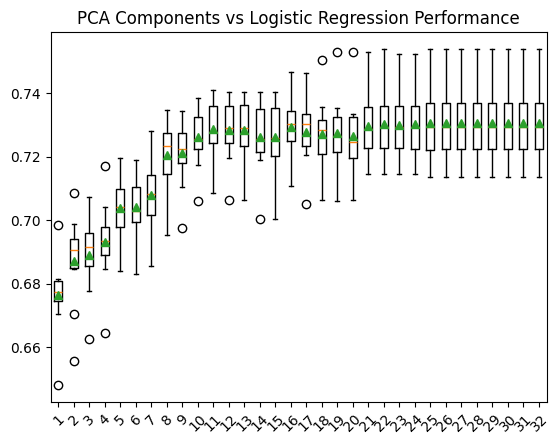

In [ ]:
X = X_train_resampled
y = y_train_resampled

def get_models():
  models=dict()
  max_features = X.shape[1]

  for i in range(1, max_features+1):
    steps = [('pca', PCA(n_components=i)),('model', LogisticRegression(max_iter=1000))]
    models[str(i)] = Pipeline(steps=steps)

  return models

  #evaluate the model
def evaluate(model, X, y):
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=1)
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    return scores
models=get_models()

results, names = list(), list()

for name, model in models.items():
    scores = evaluate(model, X, y)
    results.append(scores)
    names.append(int(name))
    print(f">{name} {mean(scores):.3f} ({std(scores):.3f})")

plt.boxplot(results, labels=names, showmeans=True)
plt.title("PCA Components vs Logistic Regression Performance")
plt.xticks(rotation=45)
plt.show()


From the graph generated above, we would selesct components 10-12 as they provide a good balance between model performance and dimensionality reduction. Accuracy increases as number of components increase, and eventually stabels off around component 10-12, after these components there is no significan t improvement, therefore we are choosing component 10-12.

In [ ]:
#train final model accurcy
fmodel=Pipeline([('pca', PCA(n_components=12)),('logistic', LogisticRegression(max_iter=1000))])

#smote
fmodel.fit(X_train_resampled, y_train_resampled)
y_pred=fmodel.predict(X_test)

accuracy=accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

#confusion  matrix
CM=confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", CM)

Test accuracy: 0.8321548195013025
Confusion Matrix:
 [[1987  255]
 [ 196  249]]


Interpret the numbers of confusion matrix:

true negatives: 1987
false positive : 255
Out of all the data, the model correctly predicted 1987 as candidates not looking for a job and incorrectly predicted 255 people as poeple looking for a job change when they weren't

true positive:249
false nagatives: 196

The model correctly predicted 249 people who are looking for a job change and the actually are looking for a job change. The model incorrectly predicted 196 people as not looking for a job change when they actually are.


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.49404761904761907
Recall: 0.5595505617977528
F1 Score: 0.5247629083245522


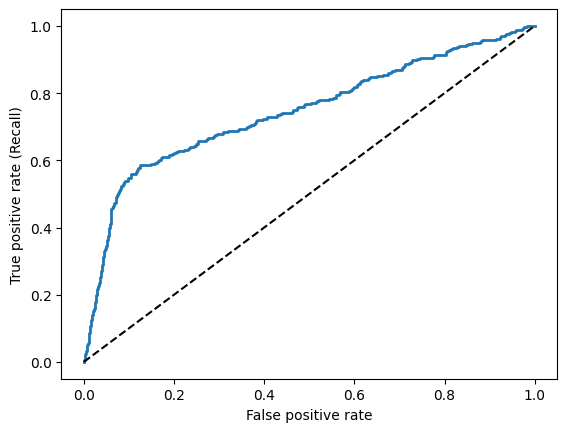

In [ ]:
from sklearn.metrics import roc_curve
y_scores = fmodel.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

def plot_roc_curve(fpr, tpr, label=None):
 plt.plot(fpr, tpr, linewidth=2, label=label)
 plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal

plot_roc_curve(fpr, tpr)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate (Recall)")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc=roc_auc_score(y_test, y_scores)
print("AUC:", roc_auc)

AUC: 0.74643526546322


Precision: 0.49404761904761907
Recall: 0.5595505617977528


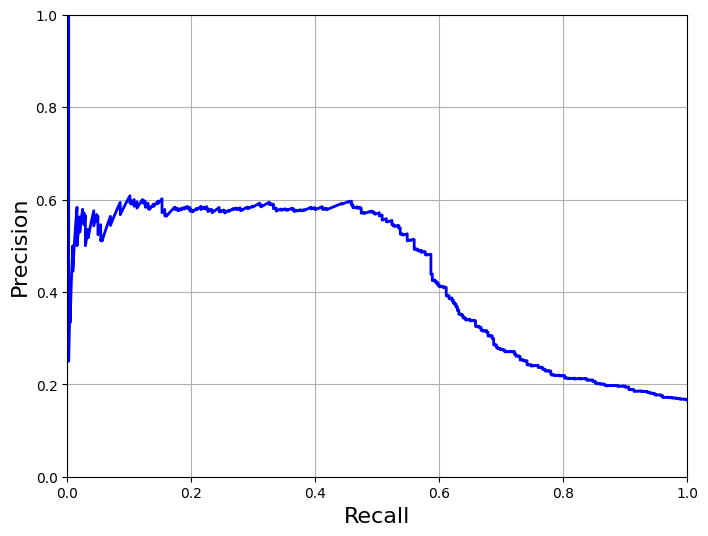

In [ ]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)
print("Precision:", precision)
print("Recall:", recall)

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)

plt.show()

Interpretation:

In the precision-recall curve, we observe the relationship between precision and recall. Around the 0.50–0.60 range, precision begins to decrease as recall increases. This shows the typical trade-off between precision and recall, where increasing one often leads to a decrease in the other. This behavior is common in imbalanced datasets. From the curve, we can conclude that the model is better at identifying positive cases (recall), although it does so at the cost of lower precision.

We also observe that about 49% of predicted job changes are actually correct, and the model correctly identifies about 56% of actual job changers.

##Softmax regression

###How softmax regression is related to logistic regression? Discuss two different libraries can be used to build soft softmax regression.

Softmax regression is a branch of logistic regression, logisitic regression is primarily used for binary classification and softmax handles multiclass classification problems and instead of using the sigmoid function to compute probabilities, softmax uses the softmax function.

Two libraries commonly used to implement softmax regression is Scikit-learn and PyTorch. Scikit-learn impelements softmax regression through multinomial logistic regression and PyTorch uses neural network layers with softmax activation function for mutliclass classification tasks.

###If we have 4 classes, 10 features, how many weights + bias will be part of the softmax model? Discuss your calculation.

weights= # of features x # of classes
weights = 10 x 4 = 40

bias = # of classes = 4



##KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred_unbalanced=knn.predict(X_test)
cm_unbalanced= confusion_matrix(y_test, y_pred_unbalanced)
print("confusion matrix (unbalanced):\n", cm_unbalanced)
print("\nclassification report (unbalanced):")
print(classification_report(y_test, y_pred_unbalanced))

confusion matrix (unbalanced):
 [[2155   87]
 [ 312  133]]

classification report (unbalanced):
              precision    recall  f1-score   support

         0.0       0.87      0.96      0.92      2242
         1.0       0.60      0.30      0.40       445

    accuracy                           0.85      2687
   macro avg       0.74      0.63      0.66      2687
weighted avg       0.83      0.85      0.83      2687



In [ ]:
knn.fit(X_train_resampled, y_train_resampled)
y_pred_balanced=knn.predict(X_test)
cm_balanced= confusion_matrix(y_test, y_pred_balanced)
print("confusion matrix (balanced):\n", cm_balanced)
print("\nclassification report (balanced):")
print(classification_report(y_test, y_pred_balanced))

confusion matrix (balanced):
 [[1701  541]
 [ 174  271]]

classification report (balanced):
              precision    recall  f1-score   support

         0.0       0.91      0.76      0.83      2242
         1.0       0.33      0.61      0.43       445

    accuracy                           0.73      2687
   macro avg       0.62      0.68      0.63      2687
weighted avg       0.81      0.73      0.76      2687



In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
knn1=KNeighborsClassifier()
#grid search, model will refit based on accuracy

grid= GridSearchCV( estimator= knn1, param_grid= param_grid,
                   scoring={ 'accuracy': 'accuracy', 'auc': 'roc_auc'},
                    refit= 'accuracy', cv=5, n_jobs=1, verbose=1)
grid.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:", grid.best_params_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}


In [ ]:
best_knn=grid.best_estimator_
y_pred = best_knn.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nclassification report:",classification_report(y_test, y_pred))

y_scores=best_knn.predict_proba(X_test)[:,1]
print("AUC:", roc_auc_score(y_test, y_scores))

Confusion Matrix:
 [[1886  356]
 [ 254  191]]

classification report:               precision    recall  f1-score   support

         0.0       0.88      0.84      0.86      2242
         1.0       0.35      0.43      0.39       445

    accuracy                           0.77      2687
   macro avg       0.62      0.64      0.62      2687
weighted avg       0.79      0.77      0.78      2687

AUC: 0.6352133428219187


In [ ]:
#PCA

knn_pca =Pipeline([('pca', PCA(n_components=12)),
    ('knn', KNeighborsClassifier(**grid.best_params_))])
knn_pca.fit(X_train_resampled, y_train_resampled)

y_pred_pca =knn_pca.predict(X_test)
print("Confusion Matrix (PCA):\n", confusion_matrix(y_test, y_pred_pca))
print("\n Classification Report (PCA): \n", classification_report(y_test, y_pred_pca))
#AUC
y_scores_pca=knn_pca.predict_proba(X_test)[:,1]
print("AUC (PCA):", roc_auc_score(y_test, y_scores_pca))

Confusion Matrix (PCA):
 [[1826  416]
 [ 237  208]]

 Classification Report (PCA): 
               precision    recall  f1-score   support

         0.0       0.89      0.81      0.85      2242
         1.0       0.33      0.47      0.39       445

    accuracy                           0.76      2687
   macro avg       0.61      0.64      0.62      2687
weighted avg       0.79      0.76      0.77      2687

AUC (PCA): 0.640933556515551


###A short discussion on the 4 models and their differences.

The four models we evalutate here are: Logistic regression with PCA, Knn on unbalanced and balanced data, and KNN with hyperparameter tuning without using PCA and then using PCA. Through this model training we observed that the KNN model with unbalanced data acheived high accuracy but performed poorly on recall as it didn't predict well on job change predictions. However when we performed KNN with balanced data(using SMOTE)we saw that recall increased slightly with the model being able to detect job changes a little better even though the accuracy decreased a little.

We then used KNN with a grid search function, this improved our metrics as the grid search function selects optimal values for neighbors, weights, and metric. This gave us much better balanced performance to our control KNN model.

For the last model we tested with we use KNN with grid search and PCA. This reduced accuracy while improving both AUC and recall. This indicates that this model was better at detecting who actually wants to change their job or not.

The observations made here shows us the trade-off between accurac and recall and how each model has its own pros and cons. We that with each model our recall got better and better while ur accuracy decreased Logisitic regression had more stable performance while the KNN models were a little less stable while being better at predicting job changes.

##Naive Bayes

Confusion Matrix:
 [[1053 1189]
 [ 107  338]]

Classifaction report:
               precision    recall  f1-score   support

         0.0       0.91      0.47      0.62      2242
         1.0       0.22      0.76      0.34       445

    accuracy                           0.52      2687
   macro avg       0.56      0.61      0.48      2687
weighted avg       0.79      0.52      0.57      2687



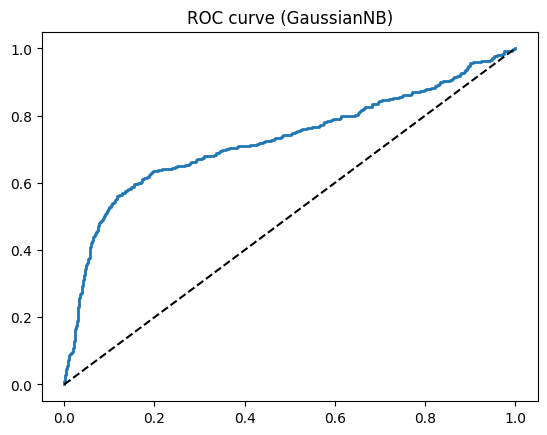

AUC: 0.7285198809249367


In [ ]:
from sklearn.naive_bayes import GaussianNB

GNB = GaussianNB()
GNB.fit(X_train_resampled, y_train_resampled)
#predict
y_pred_GNB =GNB.predict(X_test)
#confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_GNB))
#classification report
print("\nClassifaction report:\n", classification_report(y_test, y_pred_GNB))
#roc curve
y_scores_GNB=GNB.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores_GNB)
def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--')

plot_roc_curve(fpr, tpr)
plt.title("ROC curve (GaussianNB)")
plt.show()
#auc
auc_score= roc_auc_score(y_test, y_scores_GNB)
print("AUC:", auc_score)

In [ ]:
#missclassification count
cm = confusion_matrix(y_test, y_pred_GNB)

FP = cm[0][1]
FN = cm[1][0]

misclassified = FP + FN

print("Misclassified samples:", misclassified)


Misclassified samples: 1296


Confusion Matrix:
 [[1901  341]
 [ 206  239]]

Classifaction report:
               precision    recall  f1-score   support

         0.0       0.90      0.85      0.87      2242
         1.0       0.41      0.54      0.47       445

    accuracy                           0.80      2687
   macro avg       0.66      0.69      0.67      2687
weighted avg       0.82      0.80      0.81      2687



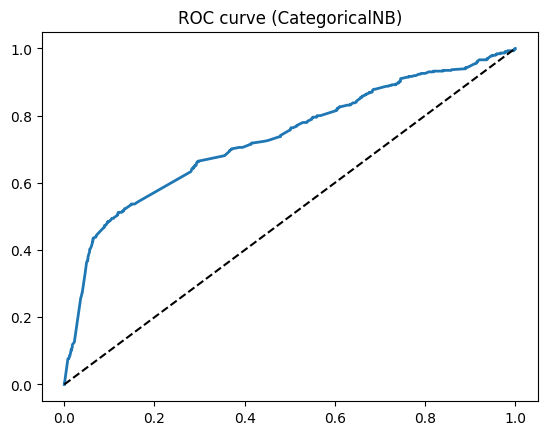

AUC: 0.7320670749431186


In [ ]:
from sklearn.naive_bayes import CategoricalNB

CNB = CategoricalNB()
CNB.fit(X_train_resampled, y_train_resampled)
#predict
y_pred_CNB =CNB.predict(X_test)
#confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_CNB))
#classification report
print("\nClassifaction report:\n", classification_report(y_test, y_pred_CNB))
#roc curve
y_scores_CNB=CNB.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores_CNB)
def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--')

plot_roc_curve(fpr, tpr)
plt.title("ROC curve (CategoricalNB)")
plt.show()
#auc
auc_score= roc_auc_score(y_test, y_scores_CNB)
print("AUC:", auc_score)

In [ ]:
#missclassification count
cm = confusion_matrix(y_test, y_pred_CNB)

FP = cm[0][1]
FN = cm[1][0]

misclassified = FP + FN

print("Misclassified samples:", misclassified)


Misclassified samples: 547


##Support Vector Machine


In [ ]:
from sklearn.svm import SVC
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

#roc calculation
#grid search for parameter tuning

svm = SVC(probability=True)

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    scoring={'accuracy': 'accuracy', 'auc': 'roc_auc'},
    refit='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

#train on SMOTE data
grid_svm.fit(X_train_resampled, y_train_resampled)
print("best Params:",grid_svm.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


Confusion Matrix:
 [[1976  266]
 [ 199  246]]

Classification Report:               precision    recall  f1-score   support

         0.0       0.91      0.88      0.89      2242
         1.0       0.48      0.55      0.51       445

    accuracy                           0.83      2687
   macro avg       0.69      0.72      0.70      2687
weighted avg       0.84      0.83      0.83      2687

AUC: 0.7291533442251602


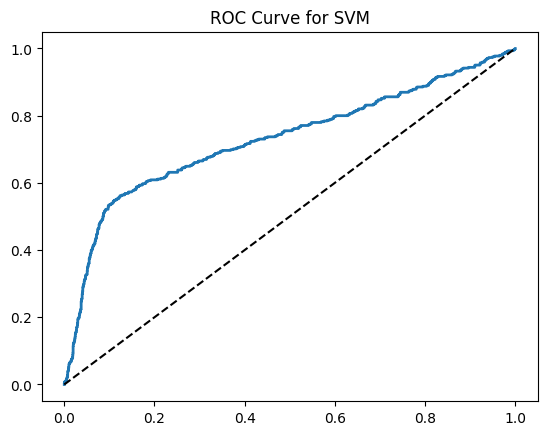

In [ ]:
#evaluate
best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:", classification_report(y_test, y_pred_svm))

#roc+ auc
y_scores_svm = best_svm.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores_svm)

auc_svm = roc_auc_score(y_test, y_scores_svm)
print("AUC:", auc_svm)

def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--')

plot_roc_curve(fpr, tpr)

plt.title("ROC Curve for SVM")
plt.show()

In [ ]:
#missclassification count
cm = confusion_matrix(y_test, y_pred_svm)

FP = cm[0][1]
FN = cm[1][0]

misclassified = FP + FN

print("Misclassified samples:", misclassified)

Misclassified samples: 465


##Decision Tree

In [ ]:
#uild a decision tree model using sklearns DecisionTreeClassifier
#unbalanced set use entropy!!!

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

dt.fit(X_train, y_train)
y_pred_dt= dt. predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Confusion Matrix:
 [[2111  131]
 [ 286  159]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.94      0.91      2242
         1.0       0.55      0.36      0.43       445

    accuracy                           0.84      2687
   macro avg       0.71      0.65      0.67      2687
weighted avg       0.83      0.84      0.83      2687



AUC: 0.7316145295632913


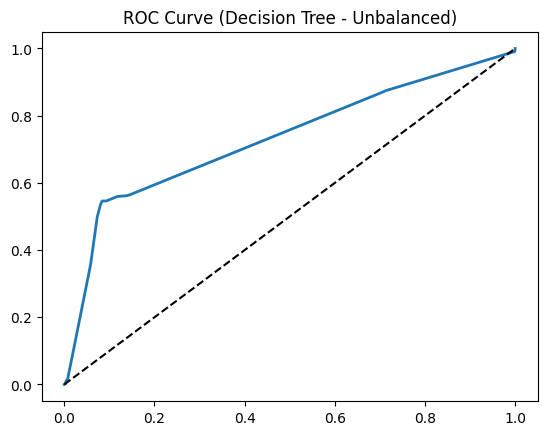

In [ ]:
y_scores_dt = dt.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores_dt)

print("AUC:", roc_auc_score(y_test, y_scores_dt))

def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--')

plot_roc_curve(fpr, tpr)
plt.title("ROC Curve (Decision Tree - Unbalanced)")
plt.show()

In [ ]:
#missclassification count
cm = confusion_matrix(y_test, y_pred_dt)

FP = cm[0][1]
FN = cm[1][0]

misclassified = FP + FN

print("Misclassified samples:", misclassified)

Misclassified samples: 417


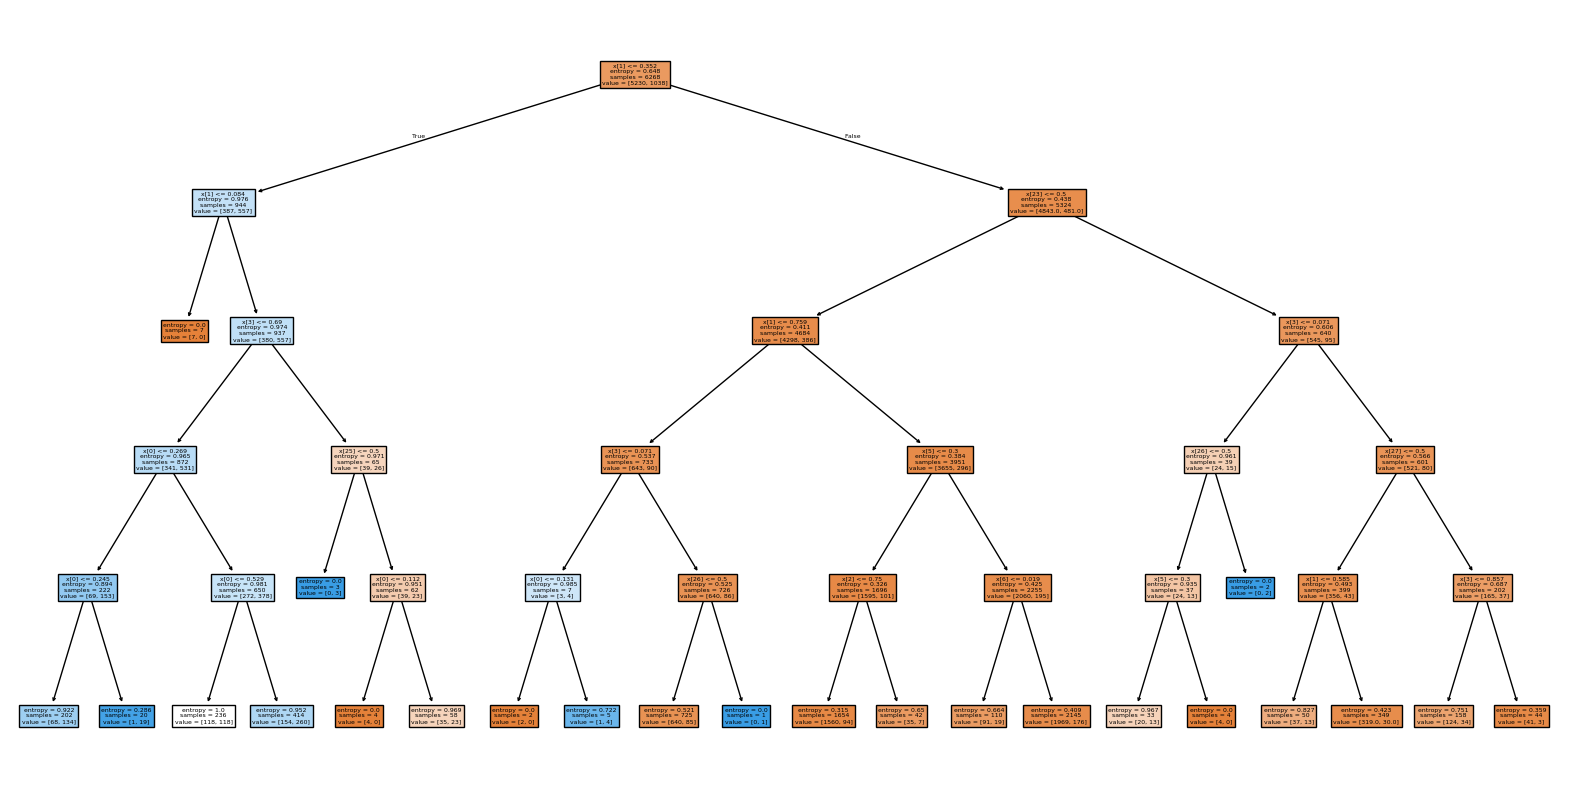

In [ ]:
from sklearn import tree

plt.figure(figsize=(20,10))
tree.plot_tree(dt, filled=True)
plt.show()

In [ ]:
#repeat with balanced
dt_bal = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)
dt_bal.fit(X_train_resampled, y_train_resampled)
# predictions
y_pred_dt_bal = dt_bal.predict(X_test)

#classification report and cms
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt_bal))

Confusion Matrix:
 [[2037  205]
 [ 207  238]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.91      0.91      2242
         1.0       0.54      0.53      0.54       445

    accuracy                           0.85      2687
   macro avg       0.72      0.72      0.72      2687
weighted avg       0.85      0.85      0.85      2687



AUC: 0.743762591586565


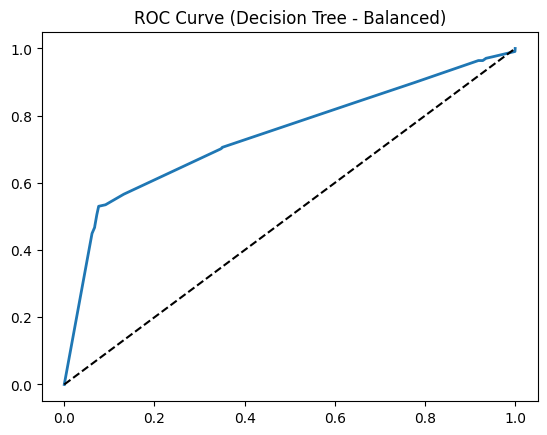

In [ ]:
y_scores_dt_bal = dt_bal.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores_dt_bal)

print("AUC:", roc_auc_score(y_test, y_scores_dt_bal))

def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--')

plot_roc_curve(fpr, tpr)
plt.title("ROC Curve (Decision Tree - Balanced)")
plt.show()

In [ ]:
#missclassification count
cm = confusion_matrix(y_test, y_pred_dt_bal)

FP = cm[0][1]
FN = cm[1][0]

misclassified = FP + FN

print("Misclassified samples:", misclassified)

Misclassified samples: 412


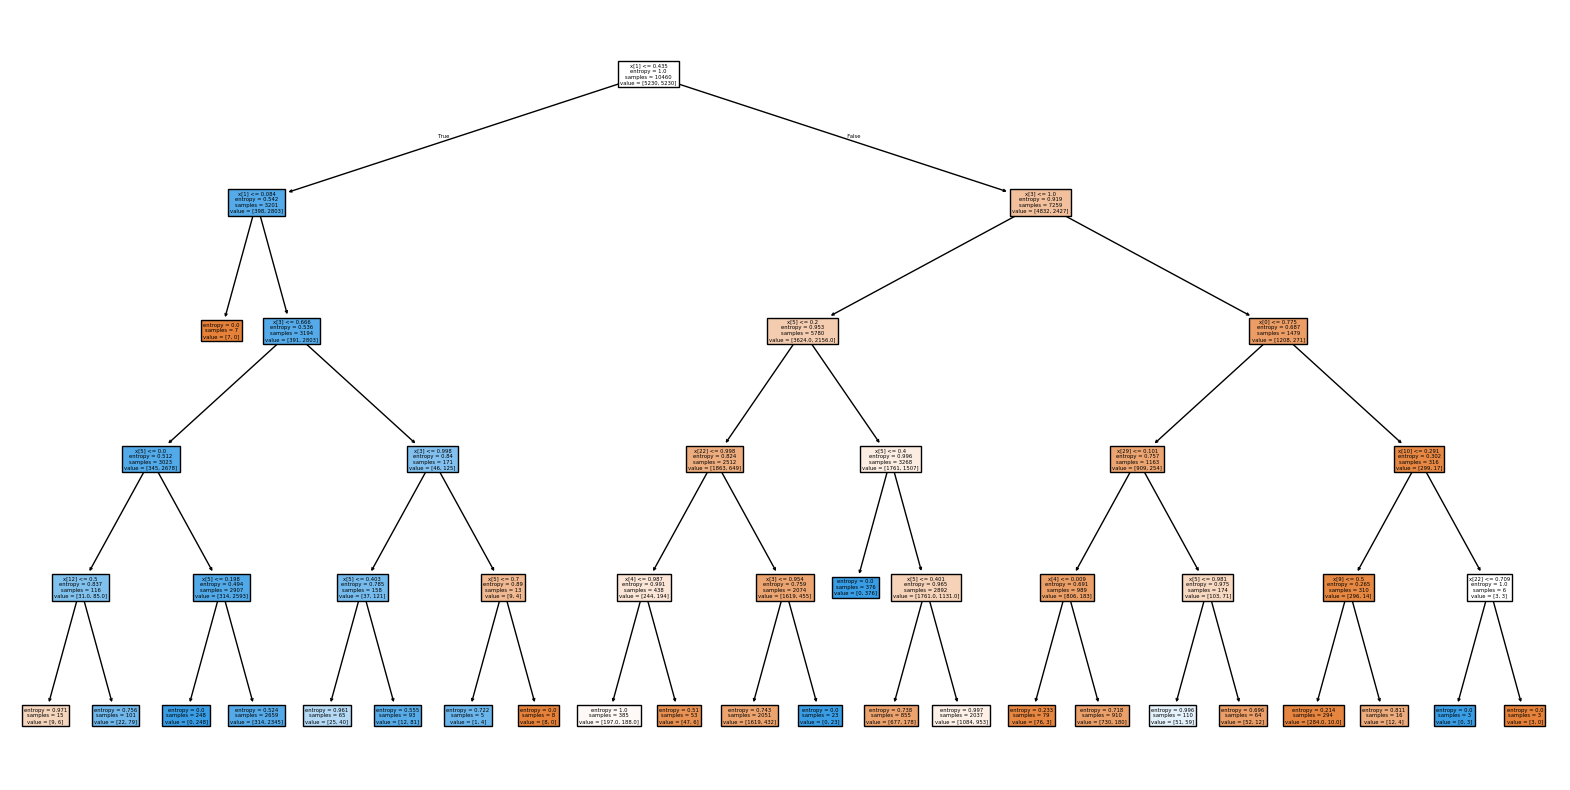

In [ ]:
from sklearn import tree

plt.figure(figsize=(20,10))
tree.plot_tree(dt_bal, filled=True)
plt.show()

###the difference between unbalanced and balanced

In the decision tree model thats trained on unbalanced data, we see that the accuracy is around 84% which indicates strong performance in predicting no job change (also seen in the high recall). However the downside of using the unbalanced dataset it that we see poor performance job changes not being correct identified with recall being 0.36. We see that the AUC performance is 0.73 which indicated an average ability to distinguish between classes.

In the decision tree model using the balance dataset we see some imporvement in performacne. We see recall for identifying candidates looking for job change have a better recall. Hoever, we see a decrease in the accuracy, demonstarting a trade-off between accuracy and minority class detection when working with datasets as such where balancing is required. Here we see a very slight improvement in the ability to distinguish between classes with a AUC of 0.74.

### Decision tree discussion

Her the decisison tree uses entropy criterion to split data based on hyperparameters that provided the most gain. We see from the tree visualization that the top has the most important feature with it trickling down to lesser important features on the bottom. The splits in the division in data group are more homogenous towards the top in terms of target variable.

We see in the unbalanced dataset that branches favor no job changes (this explains high accuracy and poor recall) while balanced tree intoduces more splits focusing on identifying job changes better.

##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(random_state=0)
param_grid_rf ={
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 4]
    }
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv = 5,
    n_jobs=-1, verbose=1,
    scoring= {'accuracy': 'accuracy', 'auc': 'roc_auc'},
    refit= 'accuracy'
    )
grid_search_rf.fit(X_train_resampled, y_train_resampled)
print("Best Estimator:", grid_search_rf.best_estimator_)

best= grid_search_rf.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Estimator: RandomForestClassifier(random_state=0)


In [ ]:
y_pred_rf = best.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Confusion Matrix:
 [[2060  182]
 [ 231  214]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.92      0.91      2242
         1.0       0.54      0.48      0.51       445

    accuracy                           0.85      2687
   macro avg       0.72      0.70      0.71      2687
weighted avg       0.84      0.85      0.84      2687



AUC: 0.749556976615983


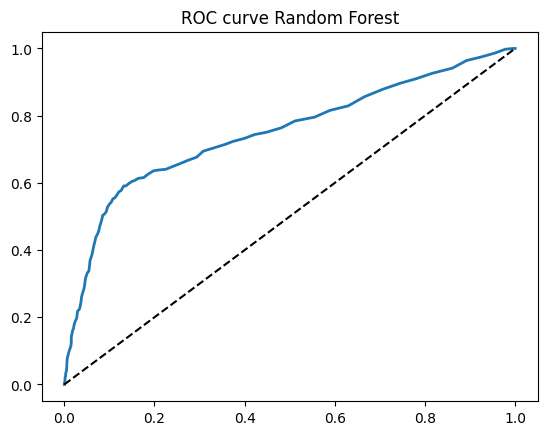

In [ ]:
y_scores_rf = best.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores_rf)

print("AUC:", roc_auc_score(y_test, y_scores_rf))

def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--')

plot_roc_curve(fpr, tpr)
plt.title("ROC curve Random Forest")
plt.show()

In [ ]:
#missclassification count
cm = confusion_matrix(y_test, y_pred_rf)

FP = cm[0][1]
FN = cm[1][0]

misclassified = FP + FN

print("Misclassified samples:", misclassified)

Misclassified samples: 413


##Boosting Algorithms

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Estimator: RandomForestClassifier(random_state=0)
Confusion Matrix (AdaBoost):
 [[2060  182]
 [ 206  239]]

Classification Report (AdaBoost):
               precision    recall  f1-score   support

         0.0       0.91      0.92      0.91      2242
         1.0       0.57      0.54      0.55       445

    accuracy                           0.86      2687
   macro avg       0.74      0.73      0.73      2687
weighted avg       0.85      0.86      0.85      2687

AUC: 0.7718569896460825


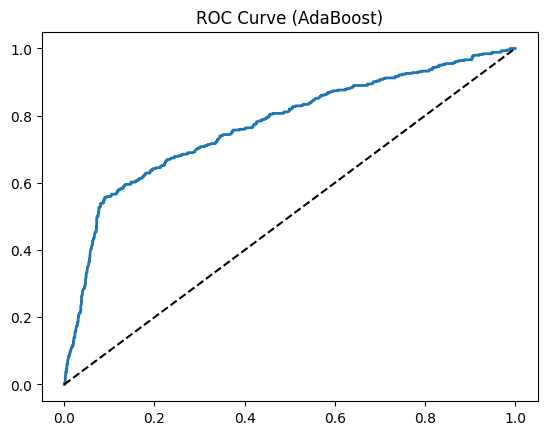

Misclassified samples: 388


In [ ]:
#Train an AdaBoostClassifier model
from sklearn.ensemble import AdaBoostClassifier
param_grid_ada = {
    'n_estimators': [50, 100],
    'learning_rate': [0.5, 1.0, 1.5]
}

ada = AdaBoostClassifier(random_state=0)

grid_ada = GridSearchCV(
    estimator=ada,
    param_grid=param_grid_ada,
    scoring={'accuracy': 'accuracy', 'auc': 'roc_auc'},
    refit='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_ada.fit(X_train_resampled, y_train_resampled)

print("Best Estimator:", grid_search_rf.best_estimator_)

# print the confusion matrix and classification report

best_a = grid_ada.best_estimator_

y_pred_ada = best_a.predict(X_test)

print("Confusion Matrix (AdaBoost):\n", confusion_matrix(y_test, y_pred_ada))
print("\nClassification Report (AdaBoost):\n", classification_report(y_test, y_pred_ada))

# plot ROC curve and show the AUC of ROC

y_scores_ada = best_a.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores_ada)

print("AUC:", roc_auc_score(y_test, y_scores_ada))

plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve (AdaBoost)")
plt.show()

#count of the number of misclassification.
cm = confusion_matrix(y_test, y_pred_ada)

FP = cm[0][1]
FN = cm[1][0]

misclassified = FP + FN

print("Misclassified samples:", misclassified)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Estimator: GradientBoostingClassifier(max_depth=5, random_state=0)
Confusion Matrix (GradientBoost):
 [[2081  161]
 [ 233  212]]

Classification Report (GradientBoost):
               precision    recall  f1-score   support

         0.0       0.90      0.93      0.91      2242
         1.0       0.57      0.48      0.52       445

    accuracy                           0.85      2687
   macro avg       0.73      0.70      0.72      2687
weighted avg       0.84      0.85      0.85      2687

AUC: 0.7538133087431967


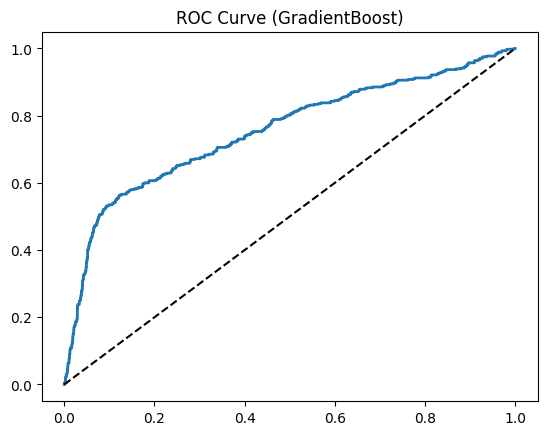

Misclassified samples: 394


In [ ]:
#Train an GradientBoostingClassifier model
from sklearn.ensemble import GradientBoostingClassifier

param_grid_gb = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3,5]
}

gb = GradientBoostingClassifier(random_state=0)
grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    scoring={'accuracy': 'accuracy', 'auc': 'roc_auc'},
    refit='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_gb.fit(X_train_resampled, y_train_resampled)

print("Best Estimator:", grid_gb.best_estimator_)

# print the confusion matrix and classification report
best_gb = grid_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)

print("Confusion Matrix (GradientBoost):\n", confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report (GradientBoost):\n", classification_report(y_test, y_pred_gb))

# plot ROC curve and show the AUC of ROC

y_scores_gb = best_gb.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores_gb)

print("AUC:", roc_auc_score(y_test, y_scores_gb))

plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve (GradientBoost)")
plt.show()

#count of the number of misclassification.
cm = confusion_matrix(y_test, y_pred_gb)

FP = cm[0][1]
FN = cm[1][0]

misclassified = FP + FN

print("Misclassified samples:", misclassified)

##Brief Discussion

In this assignment we've explored multiple models like Logistic regression, K nearest neighbors, Support Vector Machine, Naive Bayes, Decision Trees, Random Forest, and Boosting algorithms. We've seen each model display its own strengths and weakness in each feature and how well is displays class imbalance. We saw in general that any model trained with unbalanced data had a higher accuracy but poor recall. However after balancing the data using SMOTE we saw much better recall even though accuracy reduced, showing a much better performance overall.

Out of all the models we see that the most balanced algorithms were acheived through Gradient boosting as they gave us high accuracy and good recall and AUC while reducing overfitting. KNN and decision trees were also good algorithms but they were less stable while Naive bayes was faster but relied on strong assumptions. We saw that SVM was computationally expensive too.

Based on this observation we can safely assume that using Random Forest or Gradient boosting is best for this dataset as if porvides a good balance for the metrics we were measuring for job changers. I think that if we were to take this project further we can try to perform deeper hyperparameter tuning and feature selection to further see if we can get better performance in the metrics. Additionally I think adding more high quality data would never hurt and would significiatnly improve the model performance.

